# Classification Models - Dry Bean Dataset
This notebook trains and evaluates the 5 required classification models (Part A) on the preprocessed Dry Bean Dataset.

## Load Preprocessed Data
We load the scaled features and encoded targets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('colorblind')

X_train = pd.read_csv('../data/classification/X_train.csv')
X_test = pd.read_csv('../data/classification/X_test.csv')
y_train = pd.read_csv('../data/classification/y_train.csv')['Class']
y_test = pd.read_csv('../data/classification/y_test.csv')['Class']

print("Data loaded successfully.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")


Data loaded successfully.
X_train shape: (8431, 17), y_train shape: (8431,)


### Evaluation Metrics
We define a robust evaluation function that returns Accuracy, Precision, Recall, F1, and ROC-AUC (OvR) for multiclass.

In [2]:
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_true, y_pred_proba, multi_class='ovr', average='weighted')
    
    print(f"--- {model_name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    
    return {'Model': model_name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC-AUC': roc_auc}

results = []


## 1. Logistic Regression (Baseline Classifier)
Logistic Regression serves as a strong linear baseline. We will train the model and interpret its coefficients (odds).

In [4]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train, y_train)

y_pred_log = logreg.predict(X_test)
y_pred_proba_log = logreg.predict_proba(X_test)

res_log = evaluate_model(y_test, y_pred_log, y_pred_proba_log, 'Logistic Regression')
results.append(res_log)


--- Logistic Regression ---
Accuracy:  0.9080
Precision: 0.9086
Recall:    0.9080
F1 Score:  0.9081
ROC-AUC:   0.9911


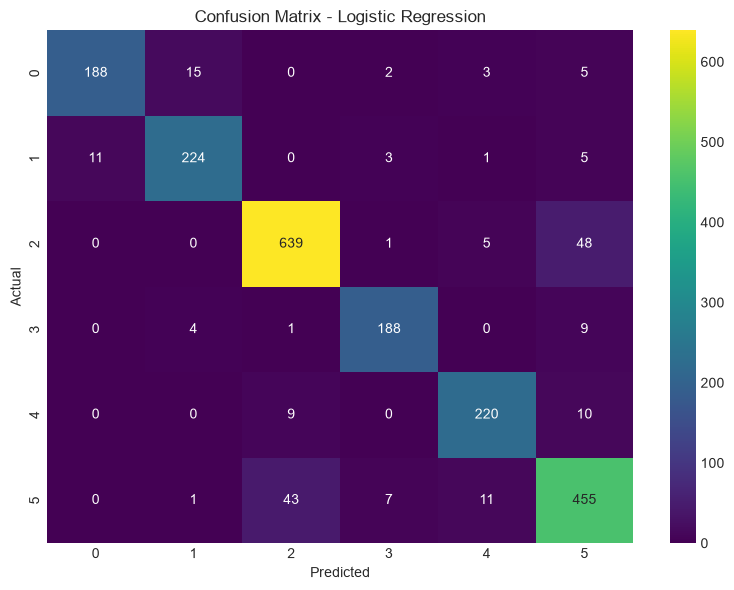

In [5]:
plt.figure(figsize=(8, 6))
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='viridis')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


### Interpreting Coefficients (Odds Ratios)
Using `OneVsRest` approach, we can inspect the coefficients. Features with higher absolute values have a stronger impact on the odds of a bean belonging to that specific class.

In [6]:
# Displaying top coefficients for Class 0 (e.g. BARBUNYA vs Rest)
coefs = logreg.coef_[0]
odds = np.exp(coefs)
coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': coefs, 'Odds_Ratio': odds})
coef_df = coef_df.sort_values(by='Odds_Ratio', ascending=False)
print("Top 5 features increasing odds for Class 0:")
print(coef_df.head())


Top 5 features increasing odds for Class 0:
            Feature  Coefficient  Odds_Ratio
3   MinorAxisLength     1.851162    6.367214
15     ShapeFactor4     1.020995    2.775954
5      Eccentricity     1.015930    2.761932
1         Perimeter     0.873806    2.396014
11      Compactness     0.831975    2.297853


## 2. K-Nearest Neighbors (KNN)
We will tune the hyperparameter `k` to balance bias and variance.

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

param_grid_knn = {'n_neighbors': [3, 5, 7, 9, 11]}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train, y_train)

print(f"Best K: {grid_knn.best_params_['n_neighbors']}")
best_knn = grid_knn.best_estimator_

y_pred_knn = best_knn.predict(X_test)
y_pred_proba_knn = best_knn.predict_proba(X_test)

res_knn = evaluate_model(y_test, y_pred_knn, y_pred_proba_knn, 'K-Nearest Neighbors')
results.append(res_knn)


Best K: 11
--- K-Nearest Neighbors ---
Accuracy:  0.9089
Precision: 0.9098
Recall:    0.9089
F1 Score:  0.9090
ROC-AUC:   0.9849


### Distance Metrics (Euclidean vs. Manhattan)
By default, `Minkowski` distance with `p=2` (Euclidean) is used. Euclidean distance calculates the straight-line distance, which works well here because our features are continuous and scaled. Manhattan (`p=1`) would calculate grid-like distance, which is sometimes preferred in high dimensions, but our feature set (~17 features) performs well with Euclidean.

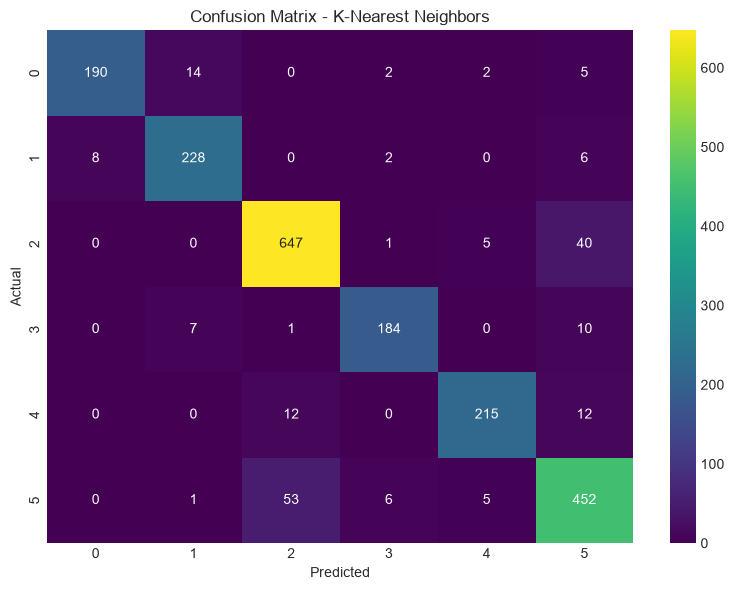

In [8]:
plt.figure(figsize=(8, 6))
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='viridis')
plt.title('Confusion Matrix - K-Nearest Neighbors')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


## 3. Naive Bayes (Gaussian)
Gaussian Naive Bayes is suitable for continuous features. 

### Conditional Independence Assumption
Naive Bayes assumes that all features are conditionally independent given the class label. While this assumption is rarely completely true in real-world data (especially here where Area, Perimeter, and Shape factors are mathematically related), the algorithm still typically performs surprisingly well as a fast, robust baseline.

In [9]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
y_pred_proba_nb = nb_model.predict_proba(X_test)

res_nb = evaluate_model(y_test, y_pred_nb, y_pred_proba_nb, 'Gaussian Naive Bayes')
results.append(res_nb)


--- Gaussian Naive Bayes ---
Accuracy:  0.8757
Precision: 0.8782
Recall:    0.8757
F1 Score:  0.8759
ROC-AUC:   0.9867


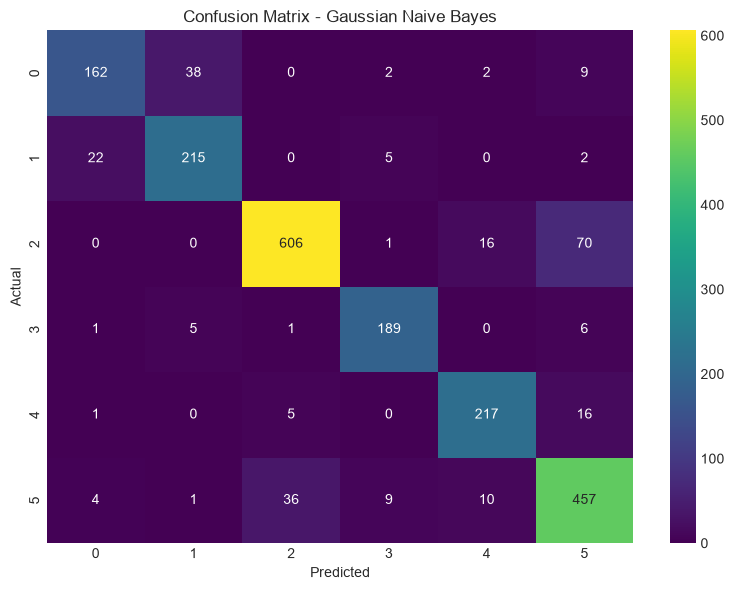

In [10]:
plt.figure(figsize=(8, 6))
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='viridis')
plt.title('Confusion Matrix - Gaussian Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


## 4. Decision Tree Classifier
Decision trees learn simple decision rules inferred from the data features. We tune `max_depth` to prevent overfitting and visualise the resulting tree.

In [11]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

param_grid_dt = {'max_depth': [3, 5, 7, 10, None]}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1)
grid_dt.fit(X_train, y_train)

print(f"Best max_depth: {grid_dt.best_params_['max_depth']}")
best_dt = grid_dt.best_estimator_

y_pred_dt = best_dt.predict(X_test)
y_pred_proba_dt = best_dt.predict_proba(X_test)

res_dt = evaluate_model(y_test, y_pred_dt, y_pred_proba_dt, 'Decision Tree Classifier')
results.append(res_dt)


Best max_depth: 7
--- Decision Tree Classifier ---
Accuracy:  0.8857
Precision: 0.8865
Recall:    0.8857
F1 Score:  0.8852
ROC-AUC:   0.9727


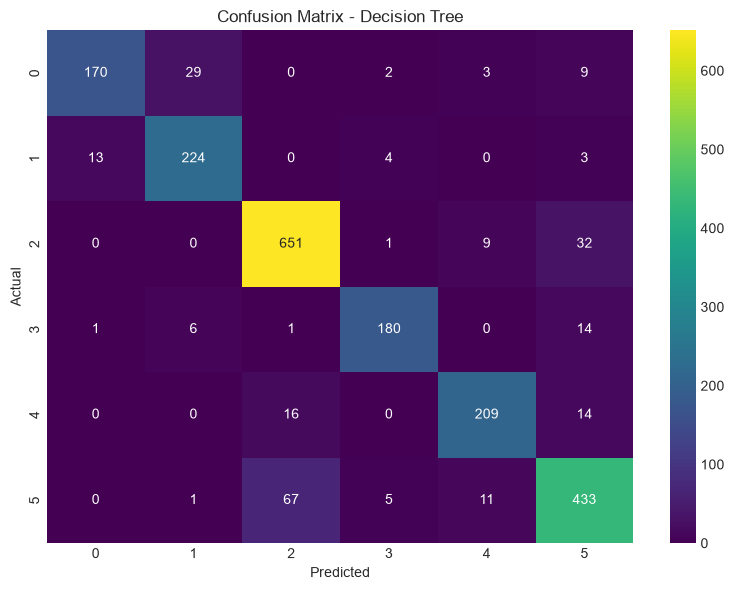

In [12]:
plt.figure(figsize=(8, 6))
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='viridis')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


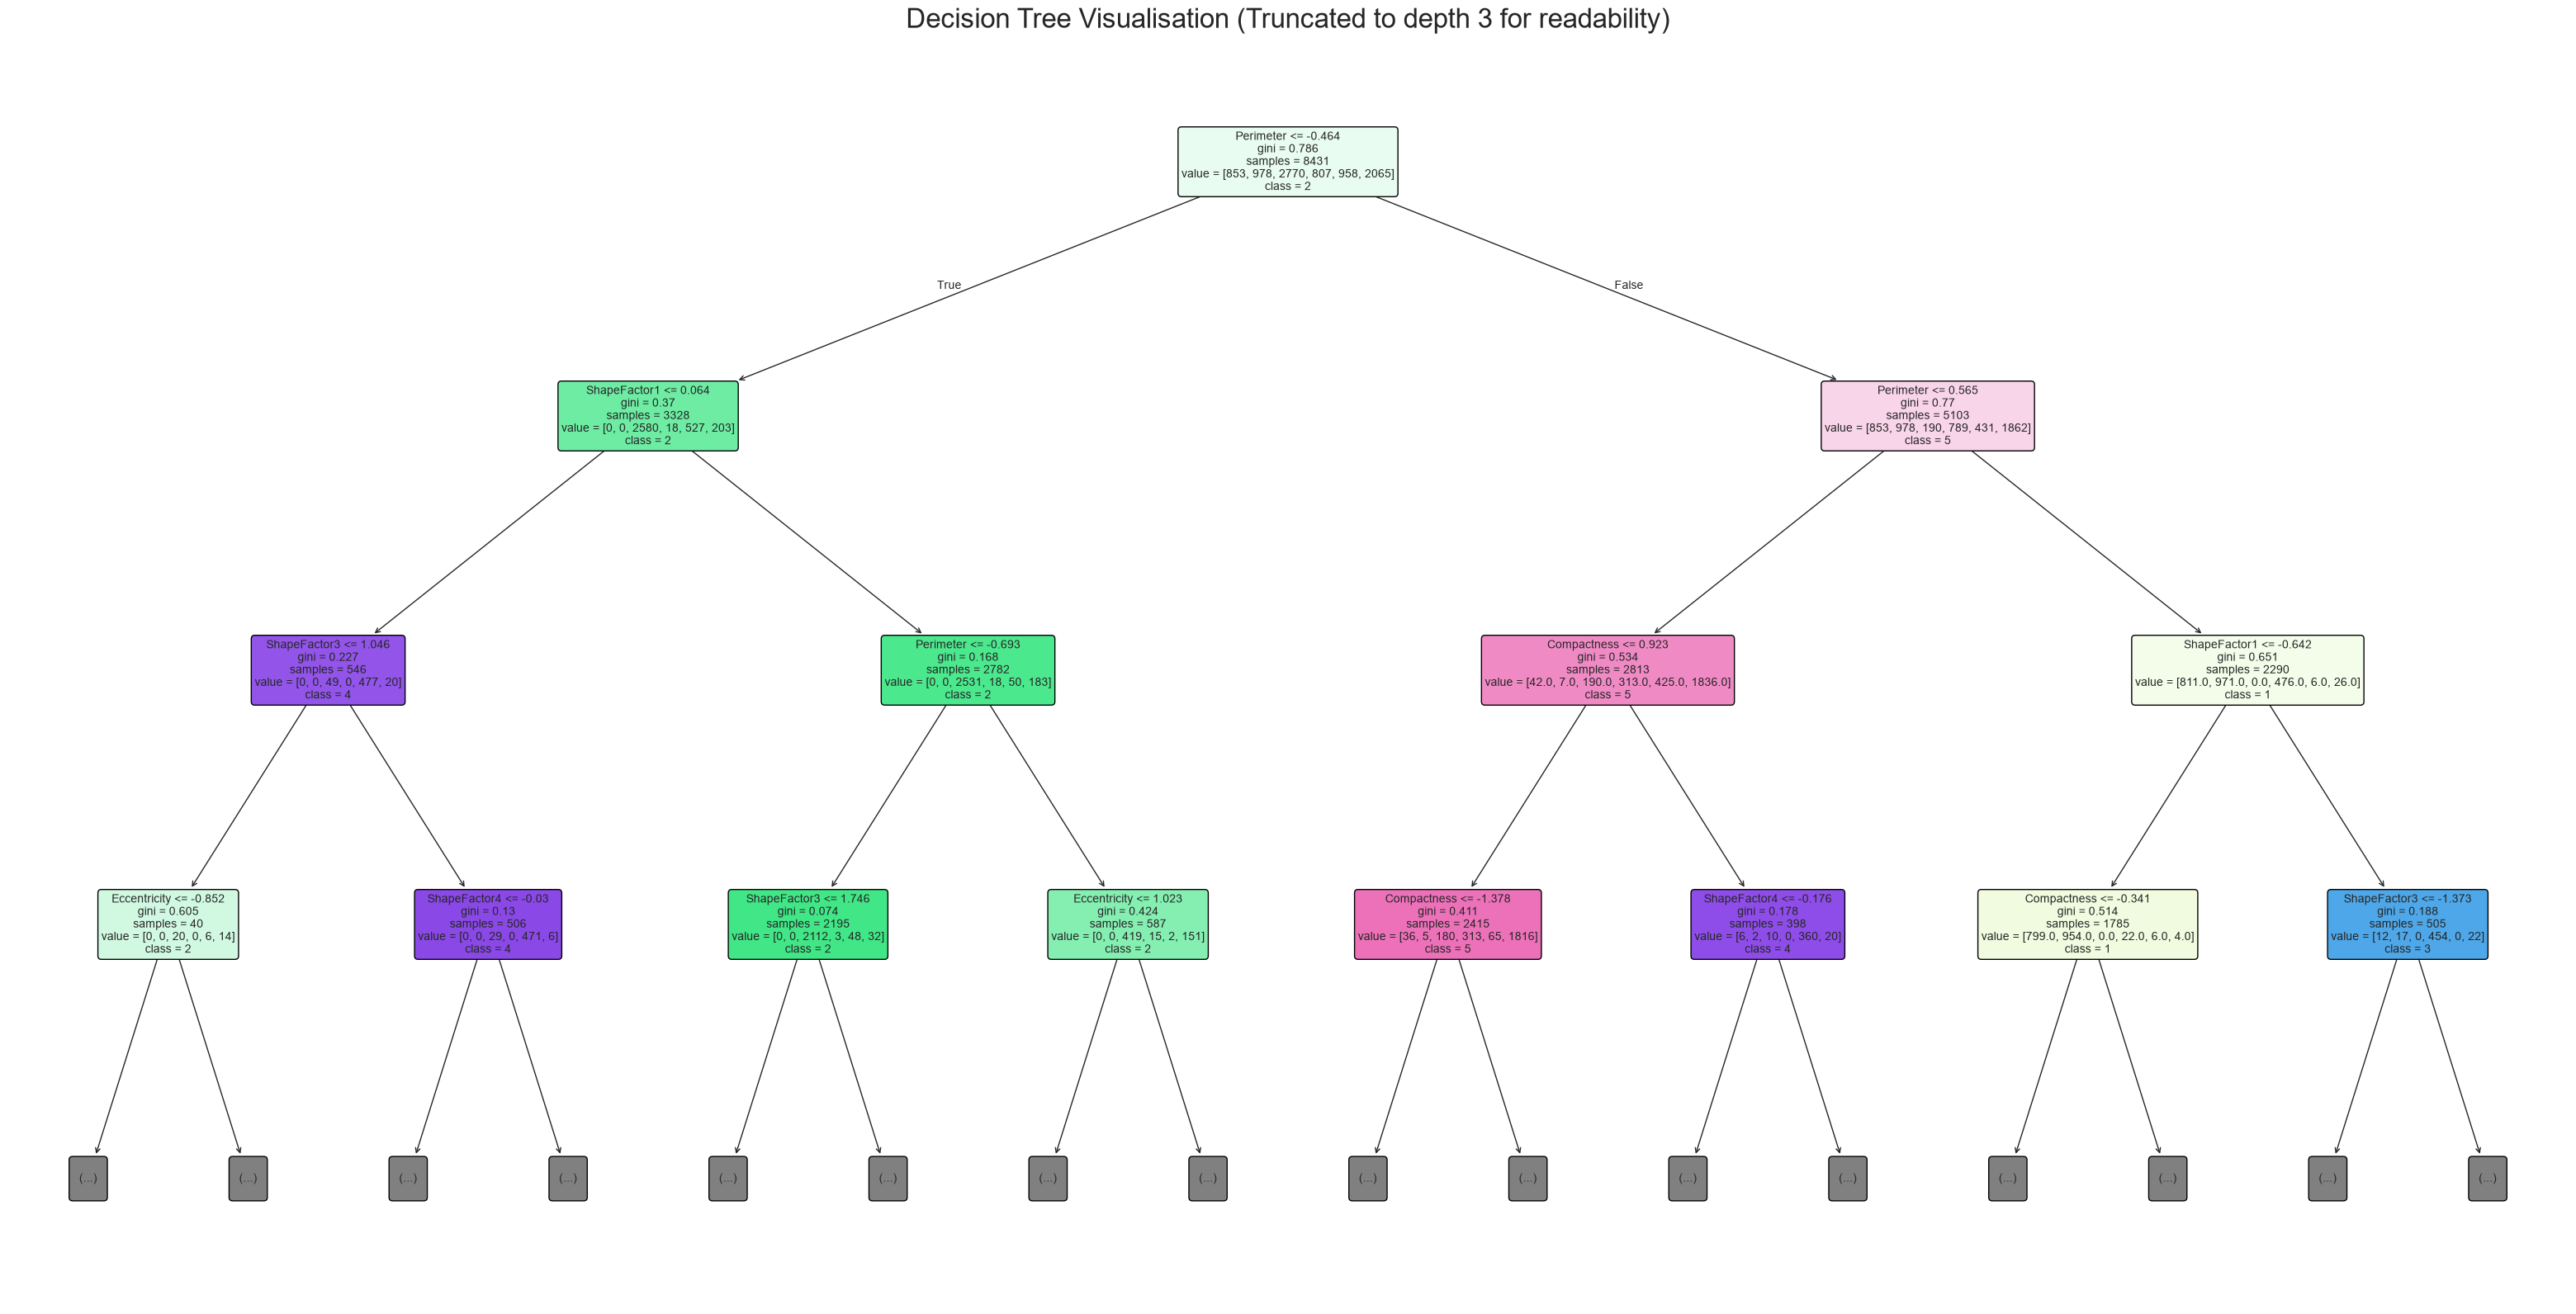

In [13]:
plt.figure(figsize=(40, 20))
plot_tree(best_dt, feature_names=X_train.columns, class_names=[str(c) for c in best_dt.classes_], filled=True, rounded=True, fontsize=10, max_depth=3)
plt.title('Decision Tree Visualisation (Truncated to depth 3 for readability)', fontsize=24)
plt.show()


## 5. Support Vector Machine (SVC)
SVMs are sensitive to feature scaling (which we handled in preprocessing). We will tune `C` and `kernel`. Since the dataset is around ~10,000 rows, SVC is tractable, but we still use a conservative grid and `probability=True` for ROC-AUC.

In [14]:
from sklearn.svm import SVC

# Because this dataset is smaller than the previous IoT dataset (~13k vs ~94k rows),
# we can safely train SVC with probability=True directly on the full train set.
param_grid_svc = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
grid_svc = GridSearchCV(SVC(probability=True, random_state=42), param_grid_svc, cv=3, scoring='accuracy', n_jobs=-1)

print("Training SVC and tuning hyperparameters...")
grid_svc.fit(X_train, y_train)

print(f"Best parameters: {grid_svc.best_params_}")
best_svc = grid_svc.best_estimator_

y_pred_svc = best_svc.predict(X_test)
y_pred_proba_svc = best_svc.predict_proba(X_test)

res_svc = evaluate_model(y_test, y_pred_svc, y_pred_proba_svc, 'Support Vector Machine (SVC)')
results.append(res_svc)


Training SVC and tuning hyperparameters...
Best parameters: {'C': 10, 'kernel': 'rbf'}
--- Support Vector Machine (SVC) ---
Accuracy:  0.9141
Precision: 0.9143
Recall:    0.9141
F1 Score:  0.9140
ROC-AUC:   0.9904


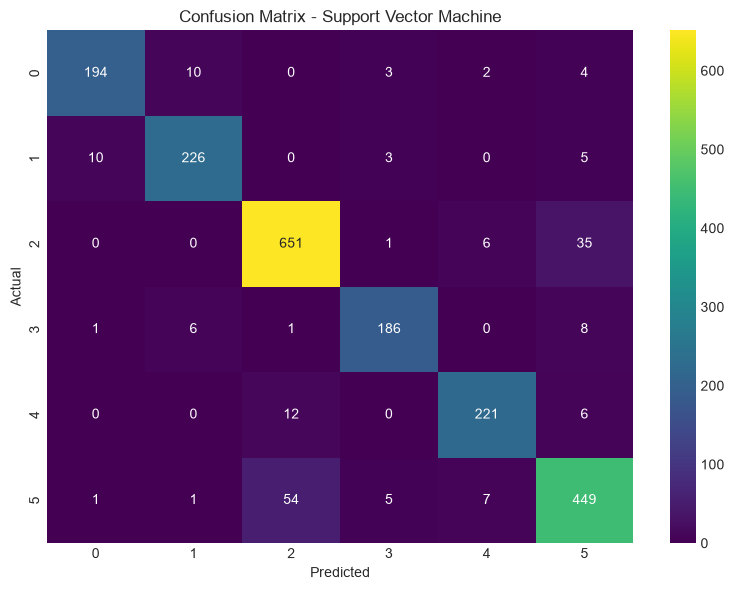

In [15]:
plt.figure(figsize=(8, 6))
cm_svc = confusion_matrix(y_test, y_pred_svc)
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='viridis')
plt.title('Confusion Matrix - Support Vector Machine')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


## Preliminary Comparison Table
A brief summary of all 5 models.

In [16]:
results_df = pd.DataFrame(results).set_index('Model')
results_df.sort_values(by='Accuracy', ascending=False)


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Support Vector Machine (SVC),0.914137,0.914269,0.914137,0.914047,0.990418
K-Nearest Neighbors,0.908918,0.909799,0.908918,0.909048,0.984927
Logistic Regression,0.907970,0.908605,0.907970,0.908136,0.991130
Decision Tree Classifier,0.885674,0.886518,0.885674,0.885161,0.972667
Gaussian Naive Bayes,0.875712,0.878163,0.875712,0.875892,0.986715
